<a href="https://colab.research.google.com/github/dityaptra/Maize-Leaf-Classification-System/blob/main/penggunaan_model_klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import library dan memuat model

In [53]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
from google.colab import files

model = tf.keras.models.load_model('maize_leaf_mobilenetv2.keras')
class_names = ['Common Rust', 'Gray Leaf Spot', 'Healthy',
               'Northern Leaf Blight', 'Not Maize Leaf']

print("Model berhasil dimuat!")
print(f"Input shape: {model.input_shape}")

Model berhasil dimuat!
Input shape: (None, 224, 224, 3)


#2. Fungsi prediksi

In [54]:
def predict_image(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((224, 224))
    img_array = np.array(img, dtype=np.float32)  # langsung, tanpa preprocessing apapun
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds)
    pred_class = class_names[pred_idx]
    confidence = 100 * np.max(preds)

    return pred_class, confidence, preds[0]

#3. Upload citra untuk mulai memprediksi

Saving Corn_Common_Rust (10).jpg to Corn_Common_Rust (10) (1).jpg


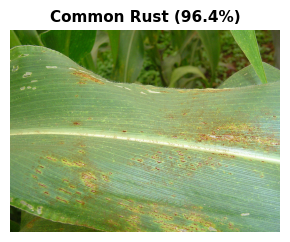


Hasil prediksi: Common Rust (96.4%)

Probabilitas semua kelas:
  Common Rust             96.4%  ████████████████████████████
  Gray Leaf Spot           0.4%  
  Healthy                  0.0%  
  Northern Leaf Blight     3.2%  
  Not Maize Leaf           0.0%  


In [55]:
uploaded = files.upload()

for fname, img_bytes in uploaded.items():
    pred_class, confidence, all_probs = predict_image(img_bytes)

    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{pred_class} ({confidence:.1f}%)", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nHasil prediksi: {pred_class} ({confidence:.1f}%)")
    print("\nProbabilitas semua kelas:")
    for name, prob in zip(class_names, all_probs):
        bar = '█' * int(prob * 30)
        print(f"  {name:<22} {prob*100:5.1f}%  {bar}")